<a href="https://colab.research.google.com/github/HeaDShoT4iK/AsilbekKI/blob/main/Amaliy%2010new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

O'qitish jarayoni boshlandi...
Epocha [1/5], Yo'qotish (Loss): 0.7588
Epocha [2/5], Yo'qotish (Loss): 0.3684
Epocha [3/5], Yo'qotish (Loss): 0.3215
Epocha [4/5], Yo'qotish (Loss): 0.2938
Epocha [5/5], Yo'qotish (Loss): 0.2712


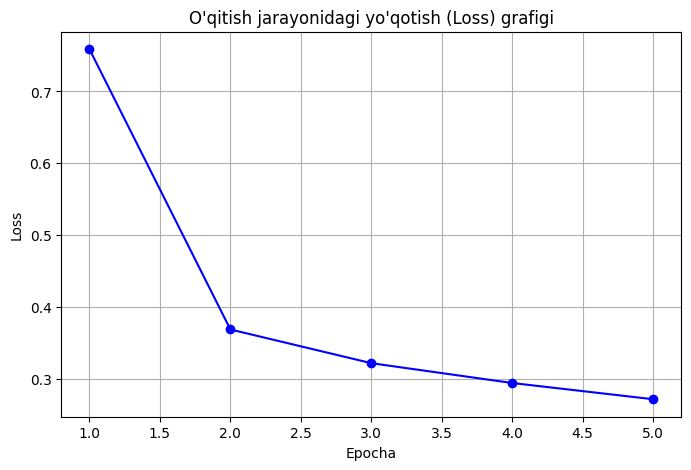

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 1. MNIST ma’lumotlarini tayyorlash
# Transformatsiya: Tasvirni Tensorga o'tkazish va normallashtirish
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Ma'lumotlarni yuklab olish
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)

# 2. Model arxitekturasini yaratish
model = nn.Sequential(
    nn.Flatten(),               # 28x28 tasvirni 784 o'lchamli vektorga aylantiradi
    nn.Linear(784, 128),        # Kiruvchi qatlam -> Yashirin qatlam
    nn.ReLU(),                  # Aktivatsiya funksiyasi
    nn.Linear(128, 10)          # Chiquvchi qatlam (10 ta raqam uchun)
)

# 3. Yo‘qotish funksiyasi va optimayzerni sozlash
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# 4. Modelni shug‘ullantirish va natijani tahlil qilish
epochs = 5
loss_history = []

print("O'qitish jarayoni boshlandi...")

for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        # Gradiyentlarni nolga tenglashtirish
        optimizer.zero_grad()

        # To'g'ri yo'nalishda hisoblash (Forward pass)
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Teskari yo'nalishda hisoblash (Backward pass)
        loss.backward()

        # Parametrlarni yangilash (Optimization)
        optimizer.step()

        running_loss += loss.item()

    # Har bir epocha uchun o'rtacha yo'qotishni hisoblash
    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)
    print(f"Epocha [{epoch+1}/{epochs}], Yo'qotish (Loss): {epoch_loss:.4f}")

# Yo‘qotish grafigini chizish
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history, marker='o', color='b', linestyle='-')
plt.title('O\'qitish jarayonidagi yo\'qotish (Loss) grafigi')
plt.xlabel('Epocha')
plt.ylabel('Loss')
plt.grid(True)
plt.show()